## Application in hippocampal pathology

**Overview**

In this tutorial, we will apply gene expression data to hippocampus-related disease, namely temporal lobe epilepsy with hippocampal sclerosis, and get a better understanding of the molecular mechanisms involved with hippocampal alterations (columnar volume and mean diffusivity).

**0 - Import libraries**

In [1]:
import os
import glob
import sys

import hippomaps as hm
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(os.path.abspath(".."))
import hippogenes as hg

/host/yeatman/local_raid/ango/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


**1 - Load gene expression data**

In [2]:
expression = hg.load_expression(data_dir="./data")

**2 - Load hippocampal alteration maps in temporal lobe epilepsy**

In [3]:
casecontrol_differences = {
    "cv": {
        "cdata": nib.load("./data/disease/casecontrol_cv.func.gii").darrays[0].data,
        "cmap": "Blues_r",
    },
    "md": {
        "cdata": nib.load("./data/disease/casecontrol_md.func.gii").darrays[0].data,
        "cmap": "Reds",
    },
}

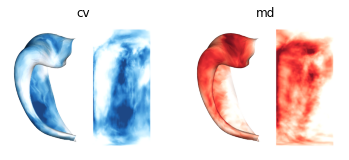

In [4]:
fig, ax = plt.subplots(1, 2)
for i, modality in enumerate(casecontrol_differences):
    x = casecontrol_differences[modality]["cdata"]
    cmap = casecontrol_differences[modality]["cmap"]
    hm.plotting.surfplot_canonical_foldunfold(x, cmap=cmap, hemis=["L"], labels=["hipp"], unfoldAPrescale=True, 
                                              share="row", tighten_cwindow=True, screenshot=True, filename=f"tmp_{i}.png")
    
    f = plt.imread(f"tmp_{i}.png")   
    ax[i].imshow(f)
    ax[i].axis('off')
    ax[i].set_anchor("NW")
    ax[i].set_title(modality)
    
!rm tmp_*.png

**3 - Correlate with disease-related risk genes**

In [5]:
risk_genes = ["C3orf33", "GJA1", "KCNAB1", "SCN1A", "SLC33A1"]

In [6]:
corr = np.full((len(casecontrol_differences), len(risk_genes)), np.nan)
pval = np.full((len(casecontrol_differences), len(risk_genes)), np.nan)

nperm = 1000
for i, modality in enumerate(casecontrol_differences):
    for j, gene in enumerate(risk_genes):
        _, _, pval[i,j], corr[i,j] = hm.stats.eigenstrapping(casecontrol_differences[modality]["cdata"], expression[gene].to_numpy(), nperm=nperm, label="hipp", den="0p5mm")

<AxesSubplot:>

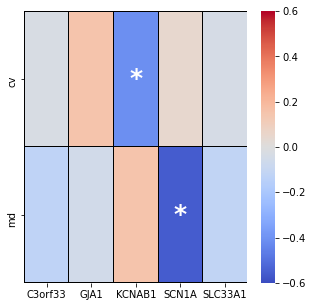

In [8]:
corr = pd.DataFrame(corr, index=casecontrol_differences.keys(), columns=risk_genes)
annot = pd.DataFrame(index=casecontrol_differences.keys(), columns=risk_genes)

for i in range(pval.shape[0]):
    for j in range(pval.shape[1]):
        if pval[i,j] < 0.05:
            annot.iloc[i, j] = "*"
        else:
            annot.iloc[i, j] = ""

f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(
    corr,
    annot=annot,
    fmt="",
    cmap="coolwarm",
    vmin=-0.6, vmax=0.6,
    linewidths=0.1,
    linecolor="black",
    annot_kws={
        "fontsize": 25,
        "fontweight": "bold",
        "color": "white",
    }
)


**4 - Correlate with virtual histology (cell types)**

In [10]:
# Cell panels
cell_types = ["Astro", "Endo", "In", "Micro", "Olig", "OPC", "Pyr"]
cell_expression = {}
for i, cell in enumerate(cell_types):
    files = glob.glob(f"./data/disease/celltype/{cell}*.tsv")
    genes = np.unique(np.concatenate([pd.read_csv(f, delimiter='\t').Gene for f in files]))
    cell_expression[cell] = expression[expression.columns.intersection(genes)]

In [11]:
n_perm = 1000

corr = np.full((len(casecontrol_differences), len(cell_types)), np.nan)
pval = np.full((len(casecontrol_differences), len(cell_types)), np.nan)

for i, modality in enumerate(casecontrol_differences):

    mri = casecontrol_differences[modality]["cdata"]
    _, permuted, _, _ = hm.stats.eigenstrapping(
        mri, mri, nperm=n_perm, den="0p5mm",
    )
    
    for j, cell in enumerate(cell_expression):
        
        # Empirical correlation
        expr = cell_expression[cell]
        tmp = np.array([
            np.corrcoef(mri, expr[gene])[0, 1]
            for gene in expr.columns
        ])
        empirical = np.median(tmp)
        corr[i, j] = empirical

        # Permutations
        null = np.full(n_perm, np.nan)
        for k in range(n_perm):
            tmp = np.array([
                np.corrcoef(permuted[:, k], expr[gene])[0, 1]
                for gene in expr.columns
            ])
            null[k] = np.median(tmp)

        pval[i,j] = ((np.sum(np.abs(null) >= np.abs(empirical))) + 1) / (n_perm + 1)

<AxesSubplot:>

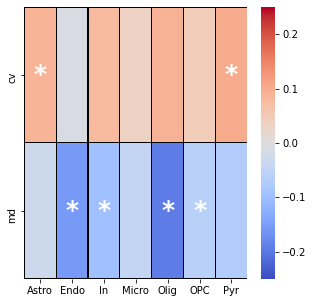

In [66]:
corr = pd.DataFrame(corr, index=casecontrol_differences.keys(), columns=cell_types)
annot = df = pd.DataFrame(index=casecontrol_differences.keys(), columns=cell_types)

for i in range(pval.shape[0]):
    for j in range(pval.shape[1]):
        if pval[i,j] < 0.05:
            annot.iloc[i, j] = "*"
        else:
            annot.iloc[i, j] = ""

f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(
    corr,
    annot=annot,
    fmt="",
    cmap="coolwarm",
    vmin=-0.25, vmax=0.25,
    linewidths=0.1,
    linecolor="black",
    annot_kws={
        "fontsize": 25,
        "fontweight": "bold",
        "color": "white",
    }
)